In [6]:
from pathlib import Path
import copy
import shutil
import numpy as np
import pycolmap
import torch

from hloc import extract_features, match_features, pairs_from_retrieval, visualization
from hloc.localize_sfm import QueryLocalizer, pose_from_cluster
from hloc.utils.parsers import parse_retrieval
from hloc.utils import viz_3d

# Bundle ve query ayarları
bundle_root = Path("../datasets/dragos-bundle")
sfm_model = bundle_root / "sparse"
images_dir = bundle_root / "images"
query_dir = bundle_root / "query"
loc_dir = bundle_root / "localization"

# Test etmek istediğin query görüntüsünü buradan değiştir
query_image_src = Path("../datasets/dragos-bundle/query/img1.jpg")
num_loc = 10

query_dir.mkdir(parents=True, exist_ok=True)
loc_dir.mkdir(parents=True, exist_ok=True)

# DB dosyaları
db_features = bundle_root / "features.h5"
db_global_features = bundle_root / "global-feats-netvlad.h5"

# Query/localization çıktıları
query_features = loc_dir / "query-features.h5"
query_global_features = loc_dir / "query-global-feats-netvlad.h5"
query_matches = loc_dir / "query-matches.h5"
loc_pairs = loc_dir / "pairs-query-netvlad.txt"
results_path = loc_dir / "query-pose.txt"

# Konfigürasyonlar
feature_conf = copy.deepcopy(extract_features.confs["superpoint_aachen"])
feature_conf["preprocessing"]["resize_max"] = 1024
retrieval_conf = extract_features.confs["netvlad"]
matcher_conf = match_features.confs["superpoint+lightglue"]

def extract_on_cpu(conf, image_root, image_list, feature_path):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    original = torch.cuda.is_available
    torch.cuda.is_available = lambda: False
    try:
        return extract_features.main(
            conf,
            image_root,
            image_list=image_list,
            feature_path=feature_path,
            overwrite=True,
        )
    finally:
        torch.cuda.is_available = original

def prepare_query_image():
    assert query_image_src.exists(), query_image_src
    query_image_dst = query_dir / query_image_src.name
    if query_image_src.resolve() != query_image_dst.resolve():
        shutil.copy2(query_image_src, query_image_dst)

    query_rel = f"query/{query_image_dst.name}"
    references = sorted([f"images/{p.name}" for p in images_dir.iterdir() if p.is_file()])
    return query_image_dst, query_rel, references

def resolve_reference_ids(model, names):
    ref_ids = []
    missing = []
    for name in names:
        image = model.find_image_with_name(name)
        if image is None:
            normalized = name.replace('\\', '/').lstrip('./')
            candidates = [normalized]
            if normalized.startswith('images/'):
                candidates.append(normalized[len('images/'):])
            else:
                candidates.append(f"images/{Path(normalized).name}")
            for candidate in candidates:
                image = model.find_image_with_name(candidate)
                if image is not None:
                    break
        if image is None:
            missing.append(name)
            continue
        ref_ids.append(image.image_id)

    if missing:
        raise ValueError(
            'SfM modelinde bulunamayan retrieval referanslari: ' + ', '.join(missing)
        )
    return ref_ids


In [7]:
# Query görüntüsünü bundle altına kopyala
query_image_dst, query_rel, references = prepare_query_image()

print(f"Query image: {query_image_dst}")
print(f"Query relative name: {query_rel}")
print(f"DB image count: {len(references)}")

Query image: ../datasets/dragos-bundle/query/img1.jpg
Query relative name: query/img1.jpg
DB image count: 3


In [8]:
# Query için global ve local öznitelik çıkarımı
# Tek query testinde OOM yaşamamak için extraction CPU üzerinde çalıştırılıyor.
query_image_dst, query_rel, references = prepare_query_image()

extract_on_cpu(
    retrieval_conf,
    bundle_root,
    [query_rel],
    query_global_features,
)

extract_on_cpu(
    feature_conf,
    bundle_root,
    [query_rel],
    query_features,
)

[2026/03/26 00:41:20 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
100%|██████████| 1/1 [00:02<00:00,  2.14s/it]
[2026/03/26 00:41:27 hloc INFO] Finished exporting features.
[2026/03/26 00:41:27 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}


Loaded SuperPoint model


100%|██████████| 1/1 [00:01<00:00,  1.08s/it]
[2026/03/26 00:41:28 hloc INFO] Finished exporting features.


PosixPath('../datasets/dragos-bundle/localization/query-features.h5')

In [9]:
# Query -> DB retrieval ve local matching
pairs_from_retrieval.main(
    descriptors=query_global_features,
    output=loc_pairs,
    num_matched=num_loc,
    query_list=[query_rel],
    db_list=references,
    db_descriptors=db_global_features,
)

match_features.main(
    matcher_conf,
    loc_pairs,
    features=query_features,
    features_ref=db_features,
    matches=query_matches,
    overwrite=True,
)

retrieval_dict = parse_retrieval(loc_pairs)
db_names = retrieval_dict[query_rel]
print("Retrieved DB images:")
for name in db_names:
    print(" -", name)

[2026/03/26 00:41:29 hloc INFO] Extracting image pairs from a retrieval database.
[2026/03/26 00:41:30 hloc INFO] Found 3 pairs.
[2026/03/26 00:41:30 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}


Using 3 registered DB images from the SfM model.


100%|██████████| 3/3 [00:00<00:00,  8.03it/s]
[2026/03/26 00:41:30 hloc INFO] Finished exporting matches.


Retrieved DB images:
 - images/IMG_20251212_152325.jpg
 - images/IMG_20251212_152607.jpg
 - images/IMG_20251212_152602.jpg


In [10]:
# Pose estimation
query_image_dst, query_rel, references = prepare_query_image()
retrieval_dict = parse_retrieval(loc_pairs)
db_names = retrieval_dict[query_rel]

model = pycolmap.Reconstruction(sfm_model)
camera = pycolmap.infer_camera_from_image(bundle_root / query_rel)
ref_ids = resolve_reference_ids(model, db_names)

conf = {
    "estimation": {"ransac": {"max_error": 12}},
    "refinement": {"refine_focal_length": True, "refine_extra_params": True},
}
localizer = QueryLocalizer(model, conf)
ret, log = pose_from_cluster(localizer, query_rel, camera, ref_ids, query_features, query_matches)

assert ret is not None, "Pose estimation failed."
results_path.write_text(
    f"{query_rel} {ret['cam_from_world'].rotation.quat[0]} {ret['cam_from_world'].rotation.quat[1]} {ret['cam_from_world'].rotation.quat[2]} {ret['cam_from_world'].rotation.quat[3]} {ret['cam_from_world'].translation[0]} {ret['cam_from_world'].translation[1]} {ret['cam_from_world'].translation[2]}\n"
)

print(f"Inliers: {ret['num_inliers']} / {len(ret['inlier_mask'])}")
print(f"Pose written to: {results_path}")

Inliers: 3 / 6
Pose written to: ../datasets/dragos-bundle/localization/query-pose.txt


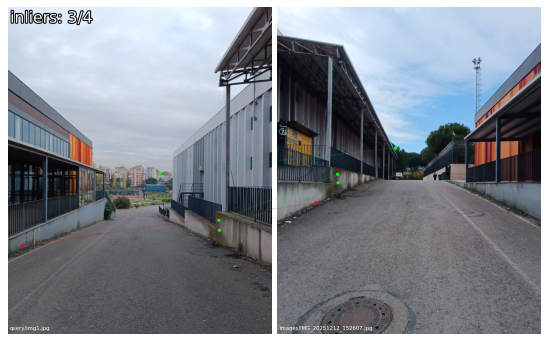

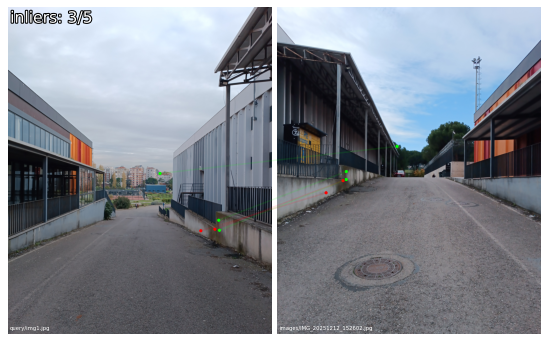

In [11]:
# 2D localization görselleştirmesi
visualization.visualize_loc_from_log(bundle_root, query_rel, log, model)

In [ ]:
# 3D reconstruction + query kamera görselleştirmesi
fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(
    fig,
    model,
    color="rgba(255,0,0,0.35)",
    name="south-building",
    points_rgb=True,
)
viz_3d.plot_camera_colmap(
    fig,
    ret["cam_from_world"],
    ret["camera"],
    color="rgba(0,255,0,0.6)",
    name=query_rel,
    fill=True,
    text=f"inliers: {ret['num_inliers']} / {ret['inlier_mask'].shape[0]}",
)
inl_3d = np.array([
    model.points3D[pid].xyz
    for pid in np.array(log["points3D_ids"])[ret["inlier_mask"]]
])
if len(inl_3d) > 0:
    viz_3d.plot_points(fig, inl_3d, color="lime", ps=2, name="query_inliers")
fig.show()